# umllm

In [1]:
import json
import pathlib

import numpy as np
import pandas as pd

In [2]:
PRICING = {
    'openai': {
        'gpt-5.4':      (2.5/1e6, 15./1e6),
        'gpt-5.4-mini': (.75/1e6, 4.5/1e6)}}

def cost(provider, model, input_tokens, output_tokens):
    try:
        l, r = PRICING[provider][model]
        return l * input_tokens + r * output_tokens
    except KeyError as err:
        return 0.
        
def load():
    for path in pathlib.Path('runs').glob('*.json'):
        with open(path, 'r', encoding='utf-8') as fp:
            t = json.load(fp)
            yield {
                'file': t['machine_file'],
                'Q': t['num_states'],
                'S': t['num_symbols'],
                'W': t['work_length'],
                'C': t['cycles_until_halt'],
                'provider': t['provider'],
                'model': t['model'],
                'temperature': t['temperature'],
                'seed': t['seed'],
                'truncate': f'yes({t["truncate"]})' if t['truncate'] is not None else 'no',
                'cycles': t['cycles'],
                'error': bool(t['error']),
                'halted': bool(t['halted']),
                # 'input_tokens': t['usage_metadata']['input_tokens'],
                # 'output_tokens': t['usage_metadata']['output_tokens'],
                'cost': cost(t['provider'],
                             t['model'],
                             t['usage_metadata']['input_tokens'],
                             t['usage_metadata']['output_tokens']),
            }
RUNS = list(load())
df = pd.DataFrame(RUNS)
df_sum = df[['error', 'halted']].sum().to_frame(name='sum')
df_cost = df[['cost']].sum().to_frame(name='$')

In [7]:
display(df_cost)
display(df_sum)
display(df.sort_values(by=['C', 'cycles']))

,$
cost,21.996359


,sum
error,168
halted,40


,file,Q,S,W,C,provider,model,temperature,seed,truncate,cycles,error,halted,cost
3,machines/Q02-S02-W128-C05-8f4bd9a80d954bcb58d5...,2,2,128,5,openai,gpt-5.4,0.0,0,no,0,True,False,0.014918
20,machines/Q02-S02-W128-C05-bd28c84b27f7c55d8b19...,2,2,128,5,openai,gpt-5.4-mini,0.0,0,yes(0),0,True,False,0.004234
39,machines/Q02-S02-W128-C05-72cae61930a854c0f33c...,2,2,128,5,openai,gpt-5.4-mini,0.0,0,no,0,True,False,0.004124
41,machines/Q02-S02-W128-C05-bd28c84b27f7c55d8b19...,2,2,128,5,openai,gpt-5.4,0.0,0,yes(0),0,True,False,0.015253
44,machines/Q02-S02-W128-C05-968fe7ea1ea4c145c618...,2,2,128,5,openai,gpt-5.4-mini,0.0,0,yes(0),0,True,False,0.004180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,machines/Q02-S02-W128-C100-5c6398884a2c5153b05...,2,2,128,100,openai,gpt-5.4-mini,0.0,0,yes(0),0,True,False,0.004331
159,machines/Q02-S02-W128-C100-622fddff499da18005a...,2,2,128,100,openai,gpt-5.4-mini,0.0,0,no,0,True,False,0.004037
163,machines/Q02-S02-W128-C100-5c6398884a2c5153b05...,2,2,128,100,openai,gpt-5.4,0.0,0,no,0,True,False,0.014978
7,machines/Q02-S02-W128-C100-622fddff499da18005a...,2,2,128,100,openai,gpt-5.4,0.0,0,no,1,True,False,0.031027


In [4]:
providers = df['provider'].unique()
models = df['model'].unique()
temperature = df['temperature'].unique()
truncate = df['truncate'].unique()
Cs = df['C'].unique()
Cs.sort()

In [5]:
import itertools
tab = {}
for p, m, temp, tr in itertools.product(providers, models, temperature, truncate):
    t = df[(df['provider'] == p) & (df['model'] == m)
        & (df['temperature'] == temp) & (df['truncate'] == tr)].sort_values('cycles')
    #display(t)
    label = f'{p}-{m}-temp:{temp}-tr:{tr}'
    for i in range(0, Cs[-1] + 1):
        N_correct = len(t[t['cycles'] >= i])
        N_total = len(t[t['C'] >= i])
        # N_correct = len(t[t['cycles'] <= i])
        # N_total = Cs[-1]
        acc = N_correct / N_total
        if label not in tab:
            tab[label] = []
        tab[label].append(acc)

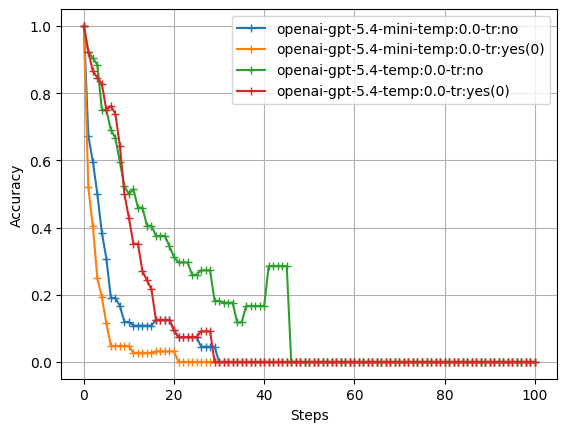

In [6]:
ax = pd.DataFrame(tab, index=list(range(0, Cs[-1]+1))).plot.line(
    xlabel='Steps', ylabel='Accuracy', grid=True, style='+-')